# Advanced Models — Train & Evaluate

**Prerequisites:** Run `data/01_build_features.ipynb`, then export notebooks for LR, RF, XGB.

**Goal:** Compare 4 models on per-snapshot accuracy. LR/RF/XGB loaded from `models/`, DNN trained inline.
Time-based 80/20 split.


In [1]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
import time as _time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from deep_neural_network import DeepNeuralNetworkRunner
from evaluator import Evaluator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
MODELS_DIR = Path("../../models")

## 1. Load data and split

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feature_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feature_cols] = df[all_feature_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])
df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[~df["candle_id"].isin(train_ids)]
y_val = df_val["target"].values

print(f"All features: {len(all_feature_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

All features: 60
Train: 173,573 rows, 3652 candles
Val:   43,122 rows, 913 candles


## 2. Load LR, RF, XGB from models/ + train DNN inline

In [3]:
# LR
lr_model = joblib.load(MODELS_DIR / "logistic_v1.joblib")
lr_scaler = joblib.load(MODELS_DIR / "scaler_v1.joblib")
lr_feat_cols = joblib.load(MODELS_DIR / "feature_cols_v1.joblib")
lr_params = lr_model.coef_.size + lr_model.intercept_.size
print(f"LR loaded: {lr_params} params, {len(lr_feat_cols)} features")

# RF
rf_model = joblib.load(MODELS_DIR / "rf_v1.joblib")
rf_scaler = joblib.load(MODELS_DIR / "rf_scaler_v1.joblib")
rf_feat_cols = joblib.load(MODELS_DIR / "rf_feature_cols_v1.joblib")
rf_params = sum(e.tree_.node_count for e in rf_model.estimators_) * 2
print(f"RF loaded: {rf_params:,} params, {len(rf_feat_cols)} features")

# XGB (calibrated)
xgb_model = joblib.load(MODELS_DIR / "xgb_calibrator_v1.joblib")
xgb_scaler = joblib.load(MODELS_DIR / "xgb_scaler_v1.joblib")
xgb_feat_cols = joblib.load(MODELS_DIR / "xgb_feature_cols_v1.joblib")
print(f"XGB loaded: {len(xgb_feat_cols)} features (calibrated)")

# DNN — train inline
print("\nTraining DNN...", flush=True)
t0 = _time.time()
dnn_scaler = StandardScaler()
X_train_dnn = dnn_scaler.fit_transform(df_train[all_feature_cols].values)
y_train_dnn = df_train["target"].values
X_dnn_tr, X_dnn_val, y_dnn_tr, y_dnn_val = train_test_split(
    X_train_dnn,
    y_train_dnn,
    test_size=0.05,
    random_state=42,
    stratify=y_train_dnn,
)
dnn = DeepNeuralNetworkRunner(X_dnn_tr, y_dnn_tr, X_dnn_val, y_dnn_val)
dnn.setup()
dnn.train(epochs=20, patience=5)
dnn_params = dnn.param_count()
print(f"DNN: {dnn_params:,} params, {len(all_feature_cols)} features ({_time.time() - t0:.1f}s)")

LR loaded: 38 params, 37 features
RF loaded: 1,478,272 params, 18 features
XGB loaded: 11 features (calibrated)

Training DNN...
  DeepNeuralNetwork: ~142,337 parameters
  Architecture: 60 -> 128 -> 4xResBlock(128) -> 1
DNN: 142,337 params
  Epoch 1/20: val_loss=0.4710 val_acc=76.1% *
  Epoch 2/20: val_loss=0.4437 val_acc=78.0% *
  Epoch 3/20: val_loss=0.4135 val_acc=80.0% *
  Epoch 4/20: val_loss=0.3797 val_acc=82.1% *
  Epoch 5/20: val_loss=0.3514 val_acc=84.1% *
  Epoch 6/20: val_loss=0.3262 val_acc=85.2% *
  Epoch 7/20: val_loss=0.3092 val_acc=86.2% *
  Epoch 8/20: val_loss=0.2954 val_acc=87.2% *
  Epoch 9/20: val_loss=0.2804 val_acc=87.6% *
  Epoch 10/20: val_loss=0.2782 val_acc=87.8% *
  Epoch 11/20: val_loss=0.2767 val_acc=87.9% *
  Epoch 12/20: val_loss=0.2757 val_acc=87.9% *
  Epoch 13/20: val_loss=0.2741 val_acc=88.0% *
  Epoch 14/20: val_loss=0.2764 val_acc=87.9%
  Epoch 15/20: val_loss=0.2649 val_acc=89.0% *
  Epoch 16/20: val_loss=0.2637 val_acc=88.5% *
  Epoch 17/20: val_

## 3. Evaluate — per-snapshot accuracy

In [4]:
all_probs = {
    "LogisticRegression": lr_model.predict_proba(lr_scaler.transform(df_val[lr_feat_cols].values))[:, 1],
    "RandomForest": rf_model.predict_proba(rf_scaler.transform(df_val[rf_feat_cols].values))[:, 1],
    "XGBoost": xgb_model.predict_proba(xgb_scaler.transform(df_val[xgb_feat_cols].values))[:, 1],
    "DNN": dnn.predict_proba(dnn_scaler.transform(df_val[all_feature_cols].values)),
}

models = [
    ("LogisticRegression", lr_params, len(lr_feat_cols)),
    ("RandomForest", rf_params, len(rf_feat_cols)),
    ("XGBoost", "calibrated", len(xgb_feat_cols)),
    ("DNN", dnn_params, len(all_feature_cols)),
]

all_results = []
print(f"{'Model':<22} {'Params':>10} {'Features':>9} {'Correct':>8} {'Total':>6} {'Accuracy':>9}")
print("-" * 68)
for name, params, n_feat in models:
    probs = all_probs[name]
    preds = (probs >= 0.5).astype(int)
    correct = int(np.sum(preds == y_val))
    total = len(y_val)
    acc = correct / total
    all_results.append(
        {"model": name, "params": params, "n_feat": n_feat, "correct": correct, "total": total, "accuracy": acc}
    )
    params_str = f"{params:,}" if isinstance(params, int) else str(params)
    print(f"{name:<22} {params_str:>10} {n_feat:>9} {correct:>8} {total:>6} {acc * 100:>8.1f}%")

Model                      Params  Features  Correct  Total  Accuracy
--------------------------------------------------------------------
LogisticRegression             38        37    31584  43122     73.2%
RandomForest            1,478,272        18    38598  43122     89.5%
XGBoost                calibrated        11    32729  43122     75.9%
DNN                       142,337        60    30465  43122     70.6%


## 4. Detailed evaluation per model

=== LogisticRegression (38 params, 37 features) ===
  Regression:      MSE=0.1723  R²=31.1%  MAE=0.3541
  Classification:  Accuracy=73.2%  Precision=70.7%  Recall=80.8%  F1=75.4%
  Samples:         43122 (UP=21875, DOWN=21247)


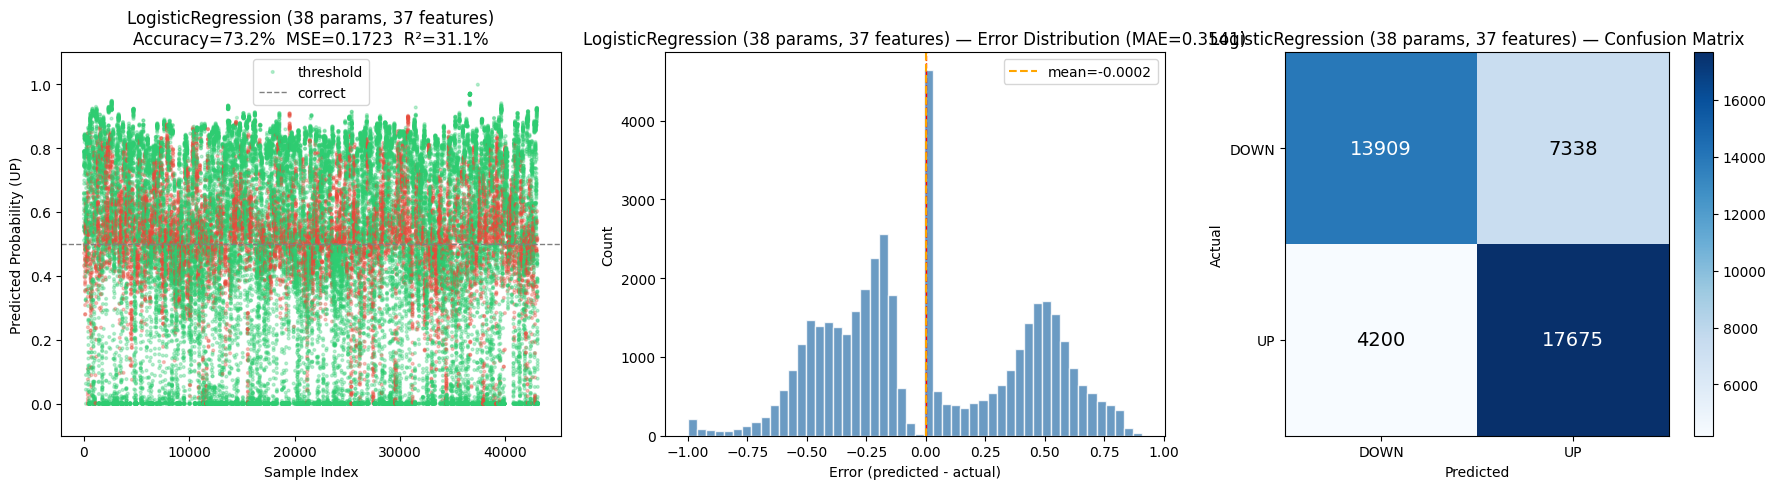


=== RandomForest (1,478,272 params, 18 features) ===
  Regression:      MSE=0.0909  R²=63.6%  MAE=0.2422
  Classification:  Accuracy=89.5%  Precision=89.5%  Recall=89.9%  F1=89.7%
  Samples:         43122 (UP=21875, DOWN=21247)


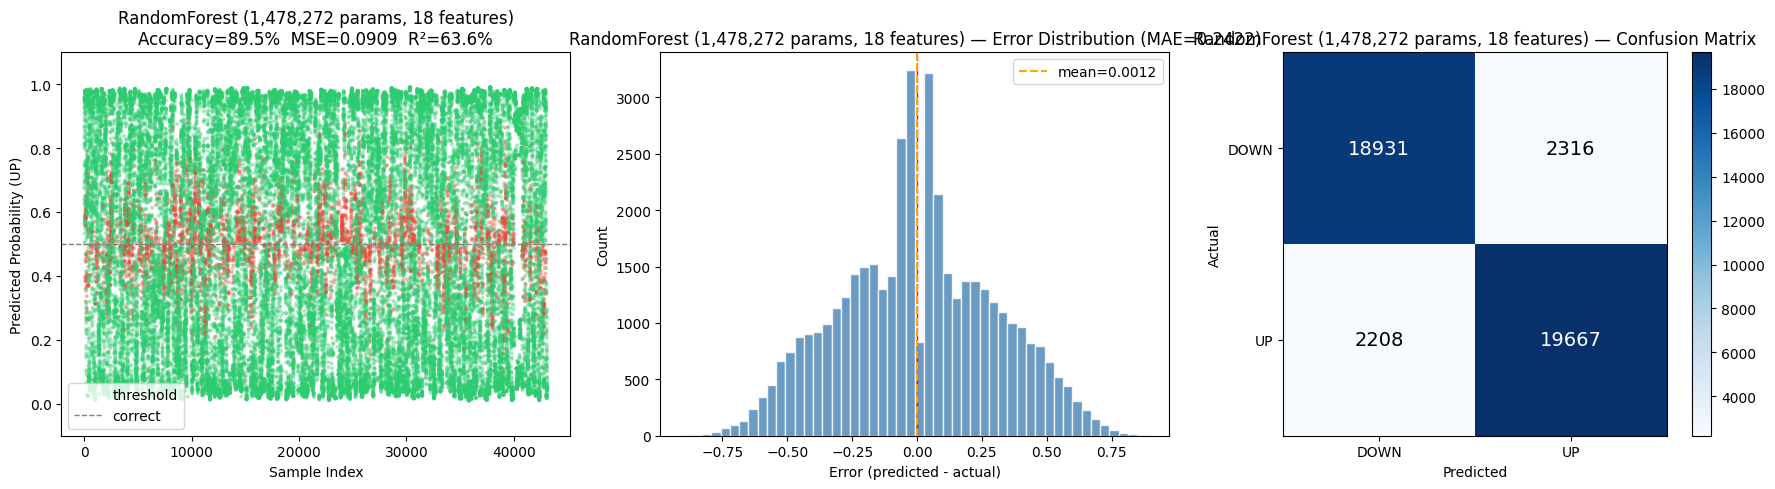


=== XGBoost (calibrated params, 11 features) ===
  Regression:      MSE=0.1605  R²=35.8%  MAE=0.3224
  Classification:  Accuracy=75.9%  Precision=76.0%  Recall=76.7%  F1=76.4%
  Samples:         43122 (UP=21875, DOWN=21247)


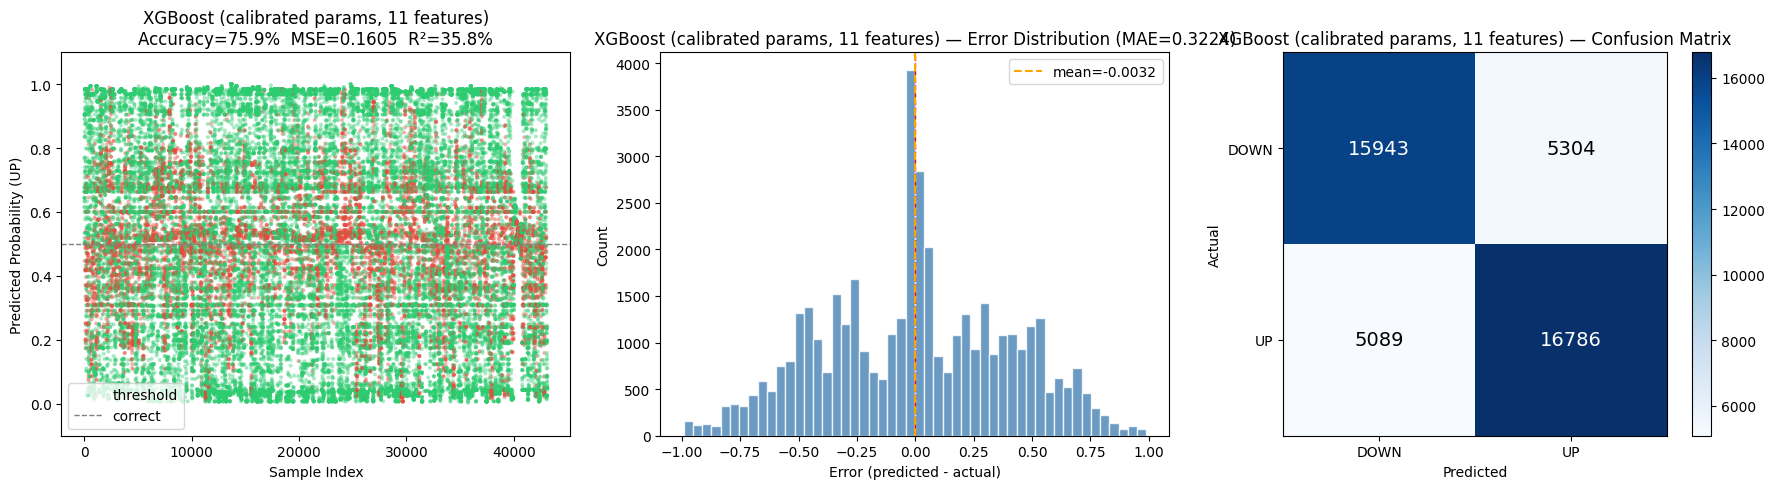


=== DNN (142,337 params, 60 features) ===
  Regression:      MSE=0.2075  R²=17.0%  MAE=0.3153
  Classification:  Accuracy=70.6%  Precision=69.7%  Recall=74.7%  F1=72.1%
  Samples:         43122 (UP=21875, DOWN=21247)


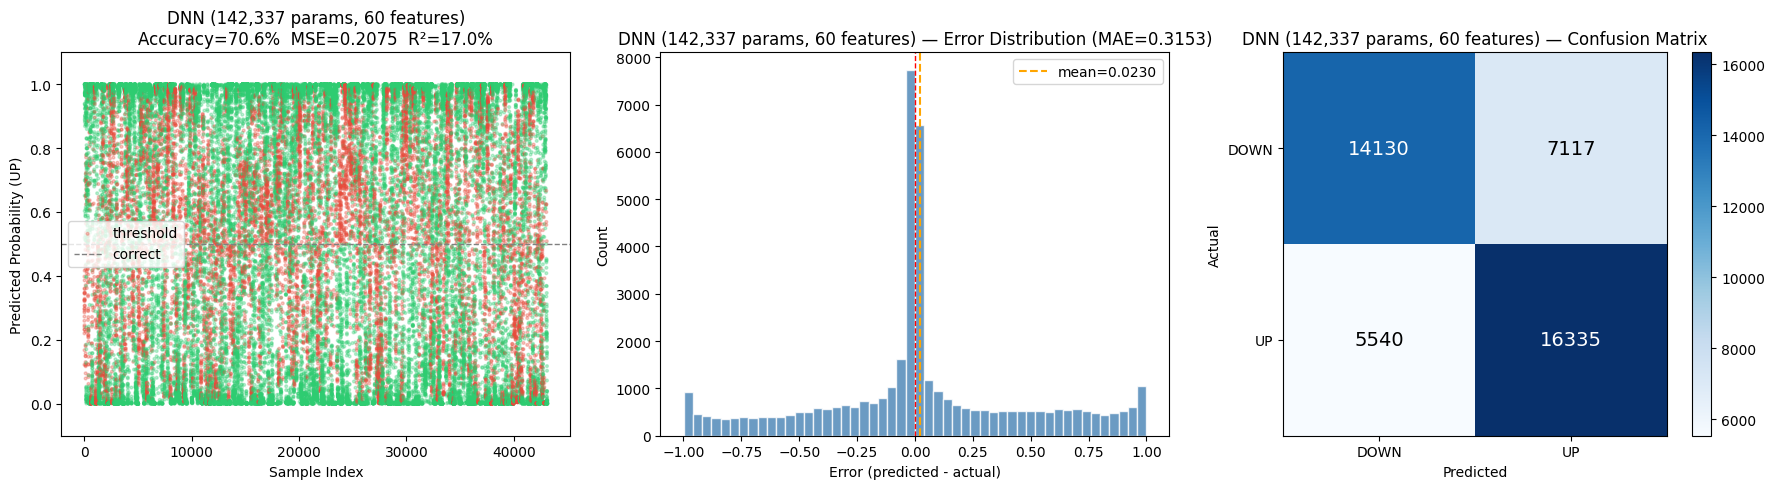

In [5]:
for name, params, n_feat in models:
    probs = all_probs[name]
    preds = (probs >= 0.5).astype(int)
    params_str = f"{params:,}" if isinstance(params, int) else str(params)
    ev = Evaluator(y_val, preds, probs, title=f"{name} ({params_str} params, {n_feat} features)")
    ev.full_report()
    print()

## 5. Comparison chart

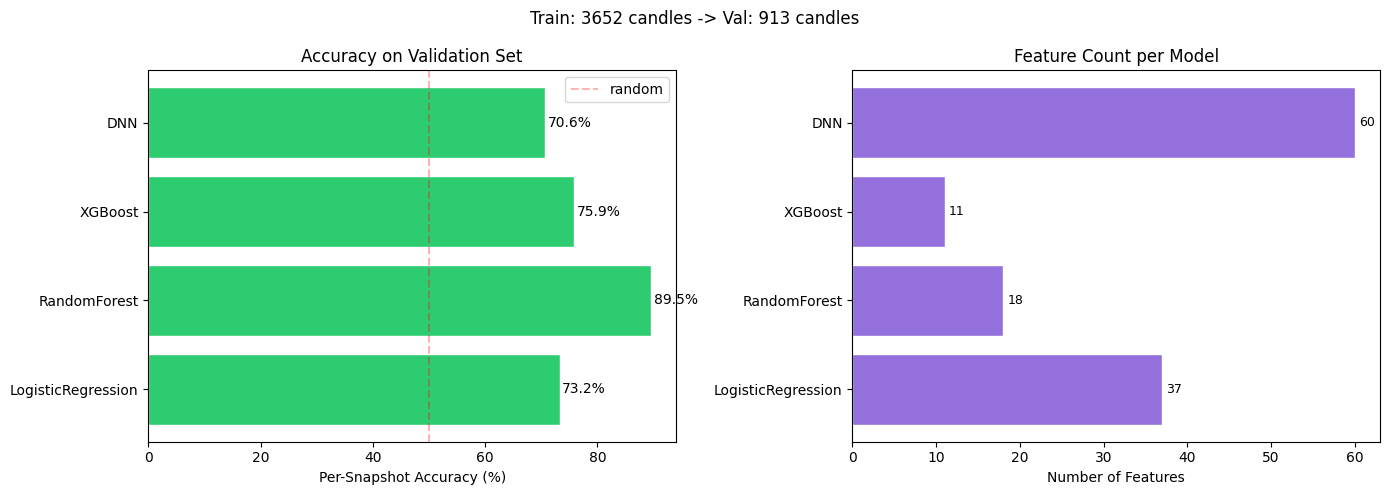

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = [r["model"] for r in all_results]
accs = [r["accuracy"] * 100 for r in all_results]
colors = ["#2ecc71" if a > 60 else "#f39c12" if a > 50 else "#e74c3c" for a in accs]
axes[0].barh(names, accs, color=colors, edgecolor="white")
axes[0].axvline(50, color="red", linestyle="--", alpha=0.3, label="random")
axes[0].set_xlabel("Per-Snapshot Accuracy (%)")
axes[0].set_title("Accuracy on Validation Set")
for i, v in enumerate(accs):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va="center")
axes[0].legend()

n_feats = [r["n_feat"] for r in all_results]
axes[1].barh(names, n_feats, color="mediumpurple", edgecolor="white")
axes[1].set_xlabel("Number of Features")
axes[1].set_title("Feature Count per Model")
for i, v in enumerate(n_feats):
    axes[1].text(v + 0.5, i, str(v), va="center", fontsize=9)

plt.suptitle(
    f"Train: {df_train['candle_id'].nunique()} candles -> Val: {df_val['candle_id'].nunique()} candles", fontsize=12
)
plt.tight_layout()
plt.show()

## 6. Conclusion

All models evaluated using **per-snapshot accuracy** on an 80/20 time-based validation split.

- **LR, RF, XGB** loaded from `models/` (no re-training)
- **DNN** trained inline (no exported model)

Re-run after updating exports (`lr/03_export`, `rf/03_export`, `xgb/03_export`).
